In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT / "src")
)

from risk_analytics import (
    historical_var,
    historical_expected_shortfall,
    rolling_var
)

In [2]:
import pandas as pd
daily_pnl = pd.read_csv(
    PROJECT_ROOT / "reports" / "daily_pnl.csv"
)

daily_pnl["date"] = pd.to_datetime(
    daily_pnl["date"])

In [3]:
var_99 = historical_var(
    daily_pnl["daily_pnl"],
    confidence=0.99
)

var_99

np.float64(92151.25490633634)

In [4]:
es_99 = historical_expected_shortfall(
    daily_pnl["daily_pnl"],
    confidence=0.99
)

es_99

np.float64(139652.44233582474)

In [5]:
daily_pnl["rolling_var_99"] = rolling_var(
    daily_pnl["daily_pnl"],
    window=250,
    confidence=0.99
)

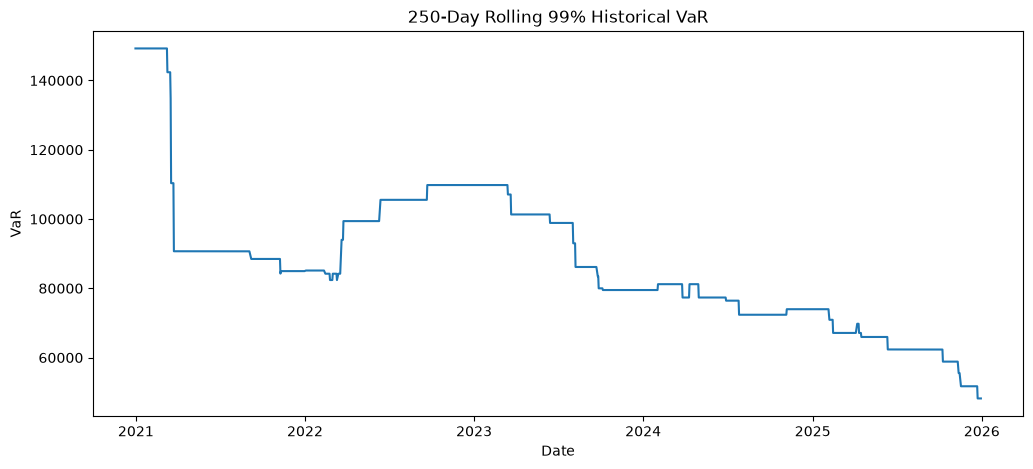

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(
    daily_pnl["date"],
    daily_pnl["rolling_var_99"]
)

plt.title("250-Day Rolling 99% Historical VaR")
plt.xlabel("Date")
plt.ylabel("VaR")

plt.show()

In [7]:
risk_metrics = pd.DataFrame({
    "metric": [
        "Historical VaR 99%",
        "Expected Shortfall 99%"
    ],
    "value": [
        var_99,
        es_99
    ]
})

risk_metrics.to_csv(
    PROJECT_ROOT / "reports" / "risk_metrics.csv",
    index=False
)

risk_metrics

,metric,value
0,Historical VaR 99%,92151.254906
1,Expected Shortfall 99%,139652.442336


In [9]:
from fx_forward import (
    forward_price,
    forward_value
)

In [10]:
spot = 1.10
strike = 1.105
domestic_rate = 0.05
foreign_rate = 0.03
time_to_maturity = 0.5
notional = 1_000_000

forward = forward_price(
    spot,
    domestic_rate,
    foreign_rate,
    time_to_maturity
)

forward

1.1106282661768825

In [11]:
value = forward_value(
    spot,
    strike,
    domestic_rate,
    foreign_rate,
    time_to_maturity,
    notional
)

value

5628.266176882502

KeyError: 'date'